In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
file_path = "/content/SN_m_tot_V2.0.csv"

df = pd.read_csv(file_path, sep=';', header=None)

# Assign column names
df.columns = [
    "Year", "Month", "DecimalDate",
    "SunspotNumber", "StdDev",
    "Observations", "Indicator"
]


In [ ]:
df.replace(-1, np.nan, inplace=True)

# Drop missing sunspot values
df = df.dropna(subset=["SunspotNumber"])

# Create datetime column
df["Date"] = pd.to_datetime(dict(year=df.Year, month=df.Month, day=1))

In [ ]:
print("\n--- Basic Statistics ---")
print("Mean:", df["SunspotNumber"].mean())
print("Median:", df["SunspotNumber"].median())
print("Std Dev:", df["SunspotNumber"].std())
print("Variance:", df["SunspotNumber"].var())
print("Min:", df["SunspotNumber"].min())
print("Max:", df["SunspotNumber"].max())



--- Basic Statistics ---
Mean: 82.19470835838845
Median: 68.45
Std Dev: 67.62555820372988
Variance: 4573.216122366057
Min: 0.0
Max: 398.2


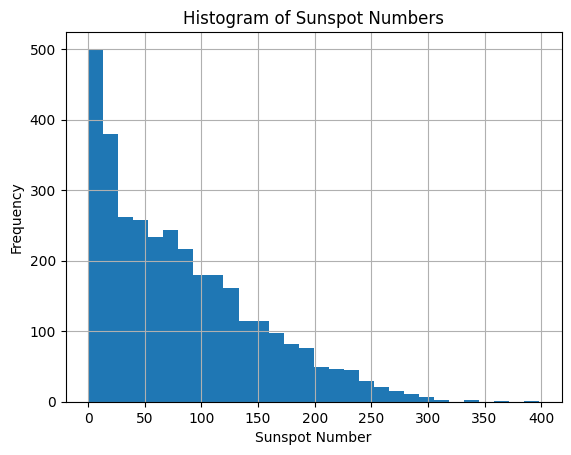

In [ ]:
# -------------------------------
# 4. DISTRIBUTION ANALYSIS
plt.figure()
df["SunspotNumber"].hist(bins=30)
plt.title("Histogram of Sunspot Numbers")
plt.xlabel("Sunspot Number")
plt.ylabel("Frequency")
plt.show()

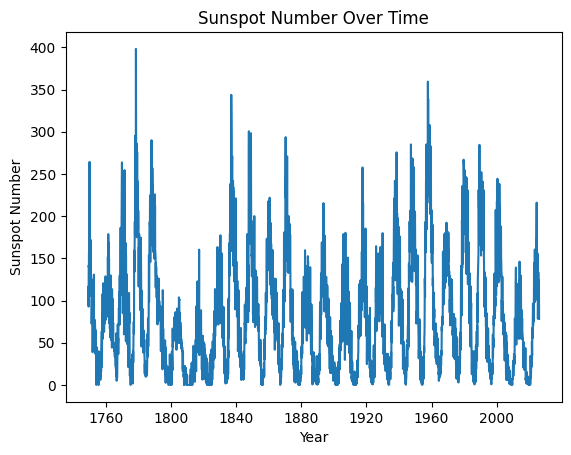

In [ ]:
# 5. TIME SERIES PLOT
plt.figure()
plt.plot(df["Date"], df["SunspotNumber"])
plt.title("Sunspot Number Over Time")
plt.xlabel("Year")
plt.ylabel("Sunspot Number")
plt.show()

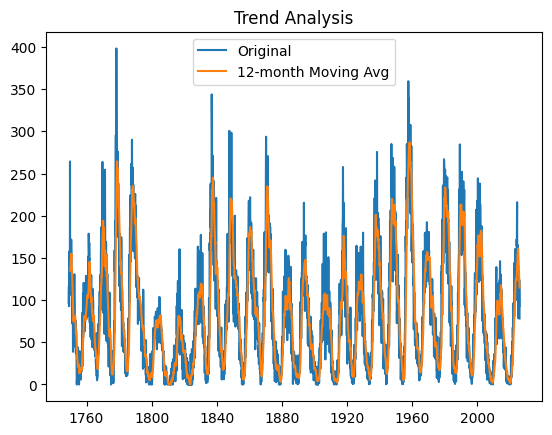


--- Outliers ---
           Date  SunspotNumber
348  1778-01-01          295.5
352  1778-05-01          398.2
353  1778-06-01          286.0
356  1778-09-01          286.2
467  1787-12-01          290.0
1055 1836-12-01          343.8
1056 1837-01-01          313.4
1057 1837-02-01          292.6
1185 1847-10-01          300.6
1200 1849-01-01          298.3
1456 1870-05-01          293.6
2504 1957-09-01          334.0
2505 1957-10-01          359.4
2506 1957-11-01          298.6
2507 1957-12-01          339.0
2508 1958-01-01          286.7
2516 1958-09-01          285.1
2520 1959-01-01          307.7

--- Yearly Statistics ---
            mean        std    max    min
Year                                     
1749  134.875000  45.368273  264.3   92.8
1750  139.000000  21.120176  171.7  105.5
1751   79.441667  26.756731  116.7   38.7
1752   79.666667  27.158569  130.7   45.2
1753   51.125000  18.527038   76.2   11.2
...          ...        ...    ...    ...
2022   83.033333  16.459997  1

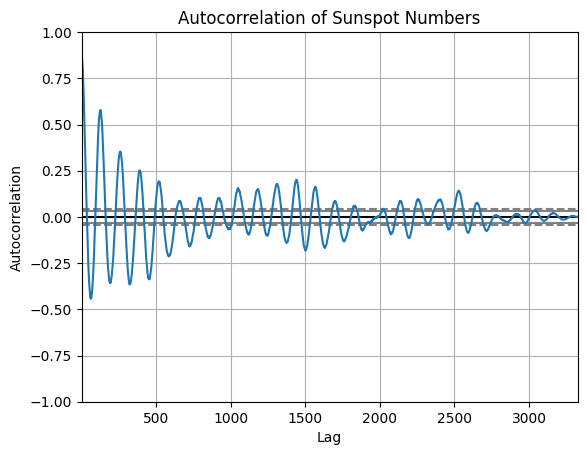

In [ ]:
# 6. MOVING AVERAGE (TREND)
df["RollingMean"] = df["SunspotNumber"].rolling(window=12).mean()

plt.figure()
plt.plot(df["Date"], df["SunspotNumber"], label="Original")
plt.plot(df["Date"], df["RollingMean"], label="12-month Moving Avg")
plt.legend()
plt.title("Trend Analysis")
plt.show()

# -------------------------------
# 7. OUTLIER DETECTION (Z-SCORE)
# -------------------------------
z_scores = (df["SunspotNumber"] - df["SunspotNumber"].mean()) / df["SunspotNumber"].std()
outliers = df[np.abs(z_scores) > 3]

print("\n--- Outliers ---")
print(outliers[["Date", "SunspotNumber"]])

# -------------------------------
# 8. YEARLY STATISTICS
# -------------------------------
yearly_stats = df.groupby("Year")["SunspotNumber"].agg(["mean", "std", "max", "min"])
print("\n--- Yearly Statistics ---")
print(yearly_stats)

# -------------------------------
# 9. AUTOCORRELATION
# -------------------------------
from pandas.plotting import autocorrelation_plot

plt.figure()
autocorrelation_plot(df["SunspotNumber"])
plt.title("Autocorrelation of Sunspot Numbers")
plt.show()

In [ ]:
high_activity = (df["SunspotNumber"] > 100).sum()
low_activity = (df["SunspotNumber"] == 0).sum()

print("\nHigh activity months (>100):", high_activity)
print("Zero sunspot months:", low_activity)

# -------------------------------
# 11. UNCERTAINTY ANALYSIS
# -------------------------------
print("\n--- Uncertainty ---")
print("Average Std Dev:", df["StdDev"].mean())
print("Average Observations:", df["Observations"].mean())


High activity months (>100): 1128
Zero sunspot months: 67

--- Uncertainty ---
Average Std Dev: 7.984987990392314
Average Observations: 165.3626901521217


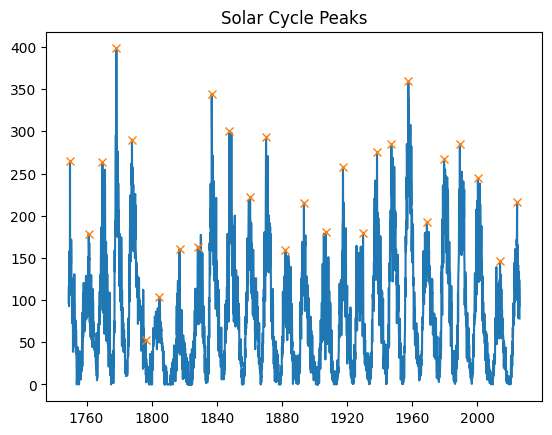

In [ ]:
# Detect solar cycle peaks
from scipy.signal import find_peaks

peaks, _ = find_peaks(df["SunspotNumber"], distance=100)

plt.figure()
plt.plot(df["Date"], df["SunspotNumber"])
plt.plot(df["Date"].iloc[peaks], df["SunspotNumber"].iloc[peaks], "x")
plt.title("Solar Cycle Peaks")
plt.show()